# Backtest Results

In [1]:
import os

import pandas as pd
from IPython.display import Image, display

# --- Configuration ---
FORMAT  = "parquet"   # "parquet" or "csv"
RESULTS = "results"

# --- Load result files ---
def _load(name: str) -> pd.DataFrame:
    path_pq  = os.path.join(RESULTS, f"{name}.parquet")
    path_csv = os.path.join(RESULTS, f"{name}.csv")
    if FORMAT == "parquet" and os.path.exists(path_pq):
        return pd.read_parquet(path_pq)
    return pd.read_csv(path_csv)

equity_df  = _load("equity_curve")
metrics_df = _load("summary_metrics")

try:
    strategy_pnl_df = _load("strategy_pnl")
    strategy_ids = [c for c in strategy_pnl_df.columns if c != "timestamp"]
except FileNotFoundError:
    strategy_pnl_df = None
    strategy_ids = []

print(f"Equity curve rows : {len(equity_df)}")
print(f"Strategy IDs      : {strategy_ids or '(none)'}")

Equity curve rows : 511
Strategy IDs      : ['SMACrossoverStrategy_0']


## 1. Equity Curve

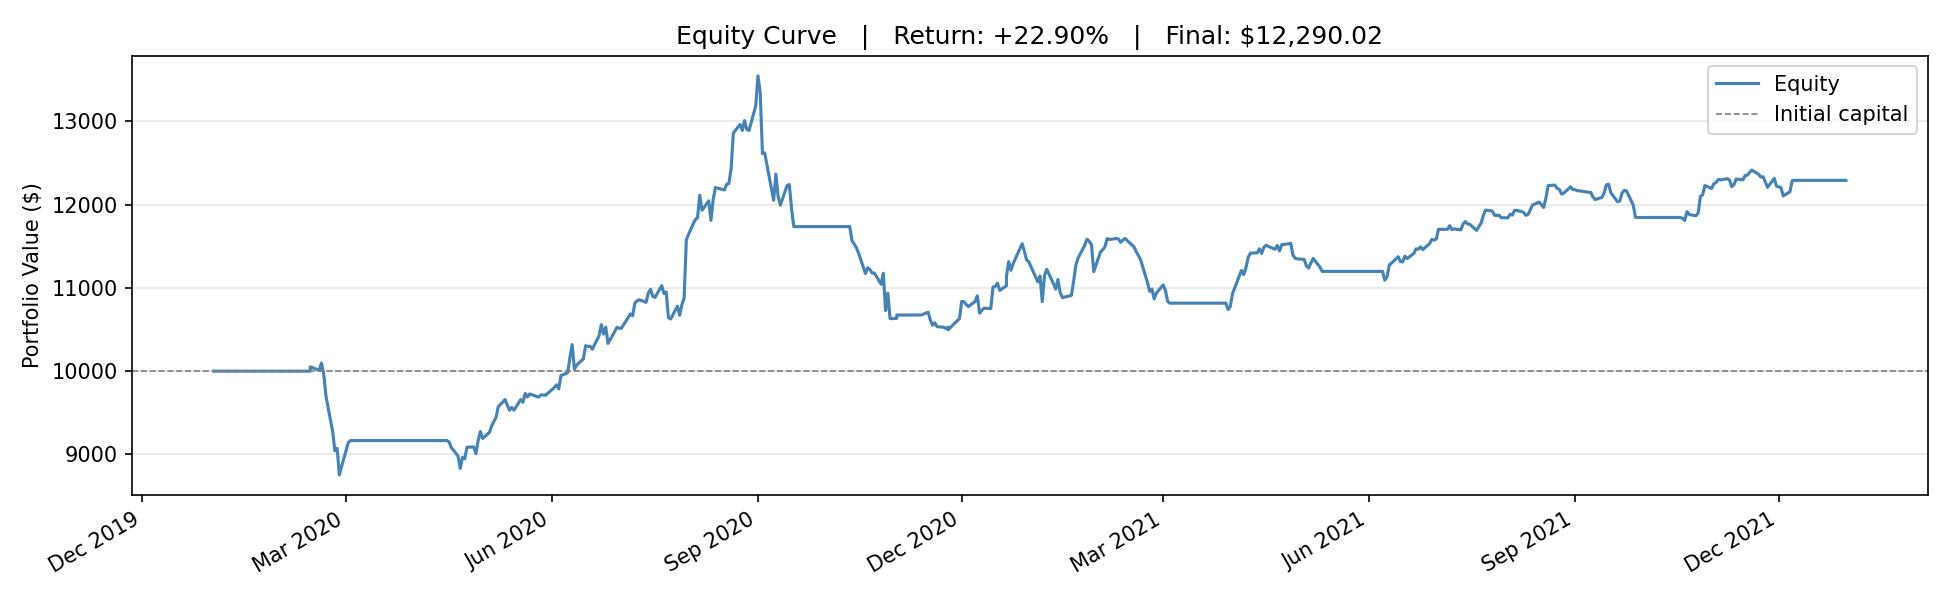

In [2]:
display(Image(os.path.join(RESULTS, "equity_curve.jpg")))

## 2. Drawdown

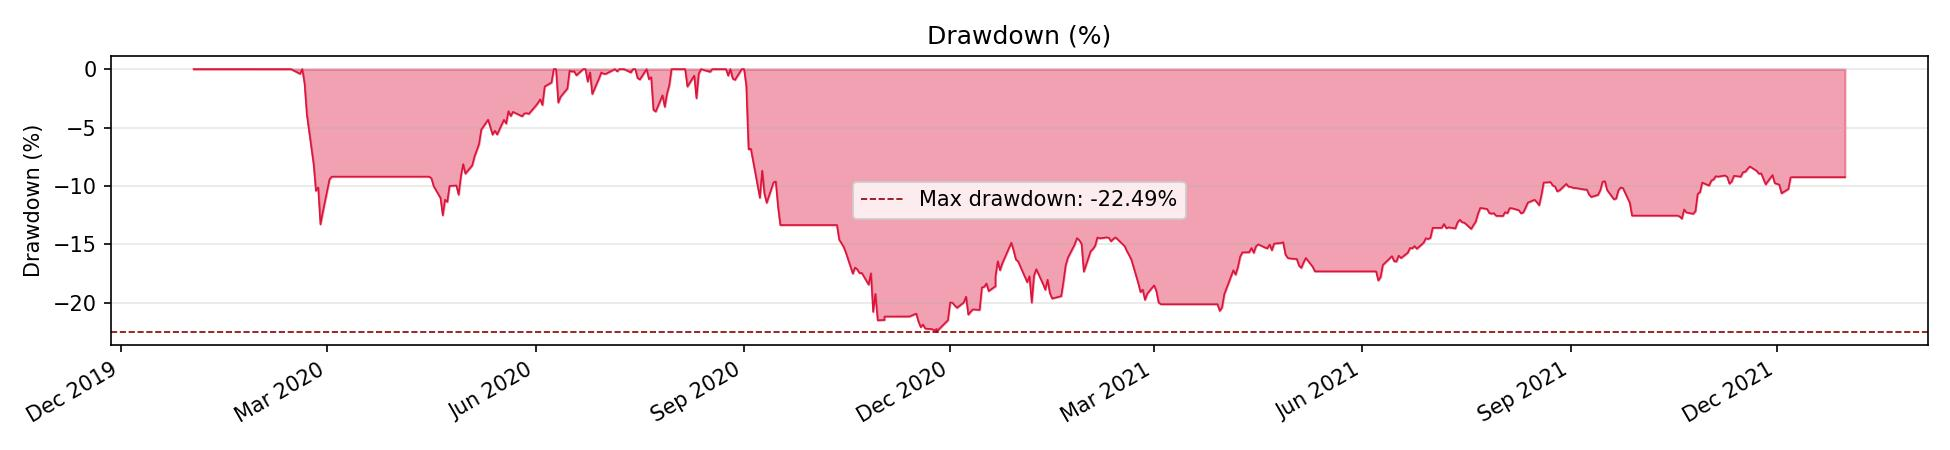

In [3]:
display(Image(os.path.join(RESULTS, "drawdown.jpg")))

## 3. Price Chart with Trade Markers

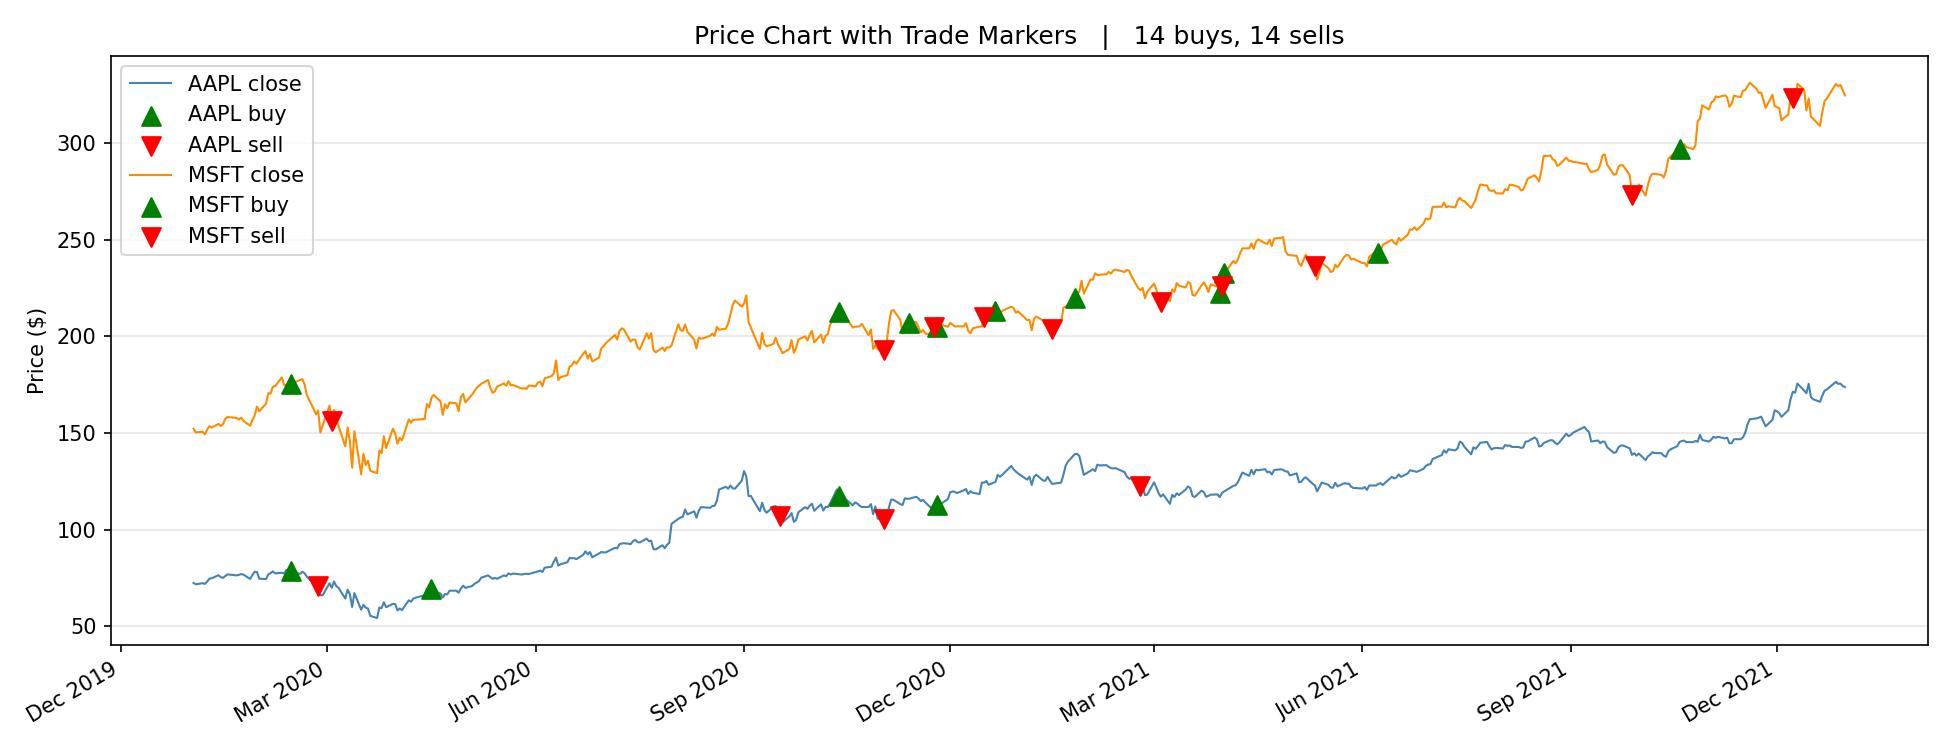

In [4]:
display(Image(os.path.join(RESULTS, "trades.jpg")))

## 4. Summary Statistics

In [5]:
m = metrics_df.iloc[0]

print("=" * 38)
print(f"  Initial capital  : ${m['initial_capital']:>10,.2f}")
print(f"  Final equity     : ${m['final_equity']:>10,.2f}")
print(f"  Total return     : {m['total_return_pct']:>+10.2f}%")
print(f"  CAGR             : {m['cagr_pct']:>+10.2f}%")
print(f"  Max drawdown     : {m['max_drawdown_pct']:>+10.2f}%")
print(f"  Sharpe (fills)   : {m['sharpe_fills']:>10.3f}")
print(f"  Number of fills  : {int(m['num_fills']):>10}")
print("=" * 38)

if strategy_ids and strategy_pnl_df is not None:
    print("\nStrategy realized PnL (final):")
    last_row = strategy_pnl_df.iloc[-1]
    for sid in sorted(strategy_ids):
        print(f"  {sid:<30} ${last_row[sid]:>+10,.2f}")

  Initial capital  : $ 10,000.00
  Final equity     : $ 12,290.02
  Total return     :     +22.90%
  CAGR             :     +10.88%
  Max drawdown     :     -22.49%
  Sharpe (fills)   :      0.046
  Number of fills  :        511

Strategy realized PnL (final):
  SMACrossoverStrategy_0         $ +2,290.02


## 5. Per-Strategy Risk Metrics

In [7]:
try:
    strat_metrics_df = _load("strategy_metrics")
    print(f"{'Strategy':<32}  {'Sharpe':>8}  {'Sortino':>8}  {'Turnover/yr':>12}")
    print("-" * 66)
    for _, row in strat_metrics_df.iterrows():
        sharpe_s  = f"{row['sharpe']:>8.3f}"  if row['sharpe']  == row['sharpe']  else "     nan"
        sortino_s = f"{row['sortino']:>8.3f}" if row['sortino'] == row['sortino'] else "     nan"
        print(f"  {row['strategy_id']:<30}  {sharpe_s}  {sortino_s}  {row['turnover_rate']:>10.1f}×")
except FileNotFoundError:
    print("No strategy_metrics file found — run the backtest first.")

Strategy                            Sharpe   Sortino   Turnover/yr
------------------------------------------------------------------
  SMACrossoverStrategy_0             0.041     0.055        10.1×


## 6. Per-Strategy Realized PnL

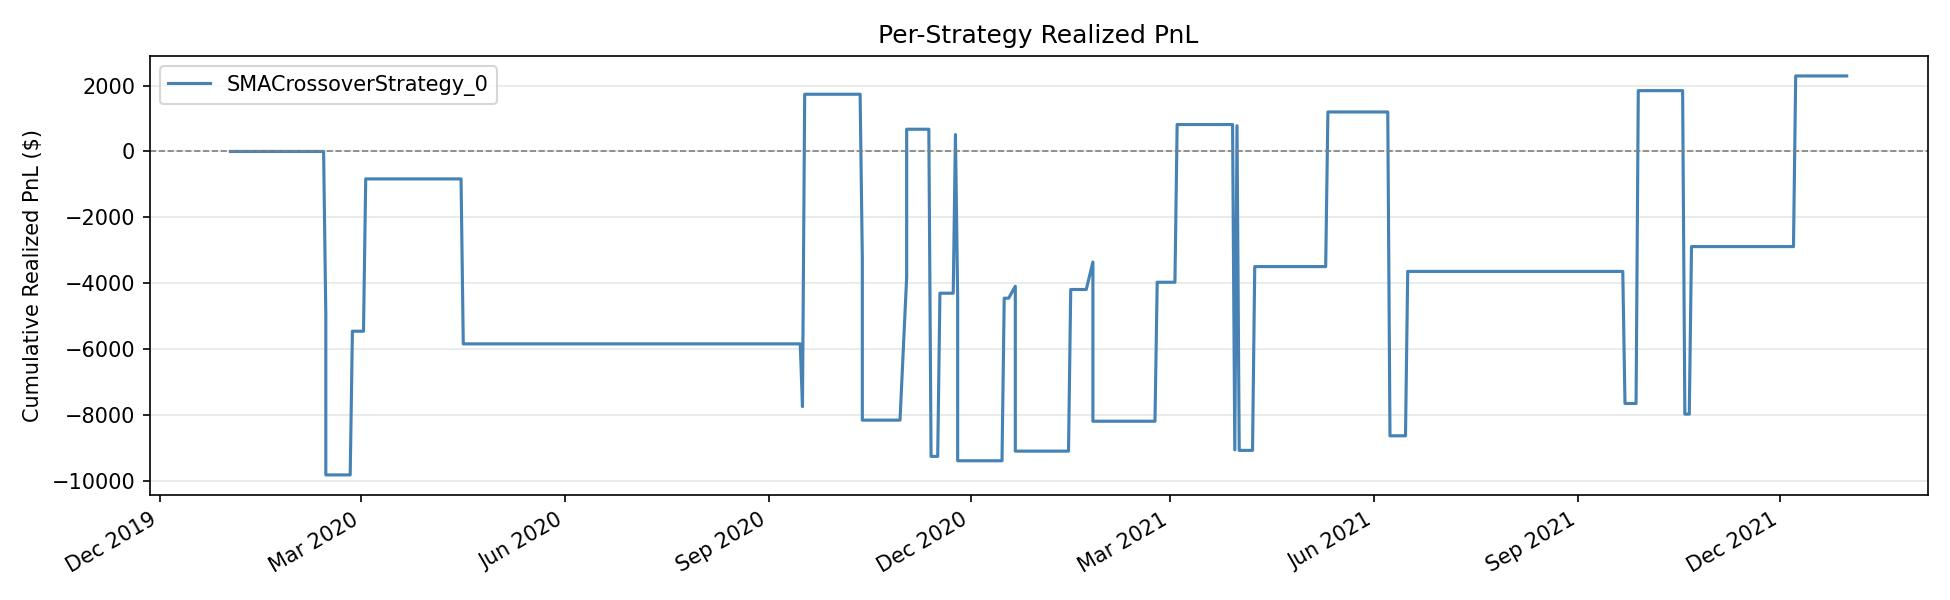

In [6]:
pnl_path = os.path.join(RESULTS, "strategy_pnl.jpg")
if os.path.exists(pnl_path):
    display(Image(pnl_path))
else:
    print("No strategy_pnl.jpg found — run the backtest first.")